In [23]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


In [25]:
data = pd.read_csv("../data/processed/pcos_processed.csv")

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
corrmat = data.corr()
corrmat["PCOS (Y/N)"].sort_values(ascending=False)

PCOS (Y/N)                1.000000
Follicle No. (R)          0.648327
Follicle No. (L)          0.603346
Skin darkening (Y/N)      0.475733
hair growth(Y/N)          0.464667
Weight gain(Y/N)          0.441047
Cycle(R/I)                0.401644
Fast food (Y/N)           0.377933
Pimples(Y/N)              0.286077
AMH(ng/mL)                0.263863
Weight (Kg)               0.211938
BMI                       0.199534
Hair loss(Y/N)            0.172879
Waist(inch)               0.164598
Hip(inch)                 0.162297
Avg. F size (L) (mm)      0.132992
Endometrium (mm)          0.106648
Avg. F size (R) (mm)      0.097690
Pulse rate(bpm)           0.091821
Hb(g/dl)                  0.087170
Vit D3 (ng/mL)            0.085494
Height(Cm)                0.068254
Reg.Exercise(Y/N)         0.065337
LH(mIU/mL)                0.063879
RBS(mg/dl)                0.048922
BP _Diastolic (mmHg)      0.038032
RR (breaths/min)          0.036928
Blood Group               0.036433
II    beta-HCG(mIU/m

In [7]:
X_test = pd.read_csv("../data/processed/pcos_test.csv").values
y_test = pd.read_csv("../data/processed/pcos_y_test.csv").values.ravel()


In [8]:
rf = joblib.load("../app/models/best_rf.pkl")


In [13]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]


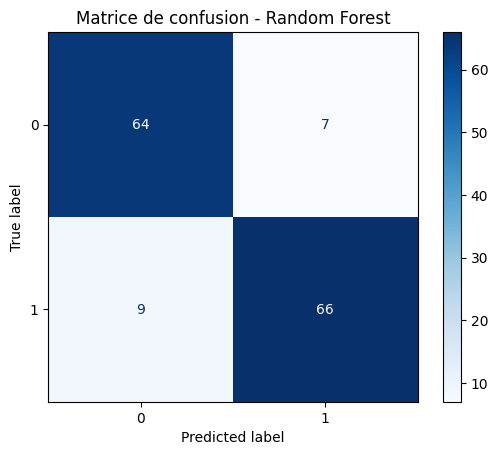

In [14]:
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Matrice de confusion - Random Forest")
plt.show()

In [16]:
print("Rapport de classification :")
print(classification_report(y_test, y_pred_rf))


Rapport de classification :
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        71
           1       0.90      0.88      0.89        75

    accuracy                           0.89       146
   macro avg       0.89      0.89      0.89       146
weighted avg       0.89      0.89      0.89       146



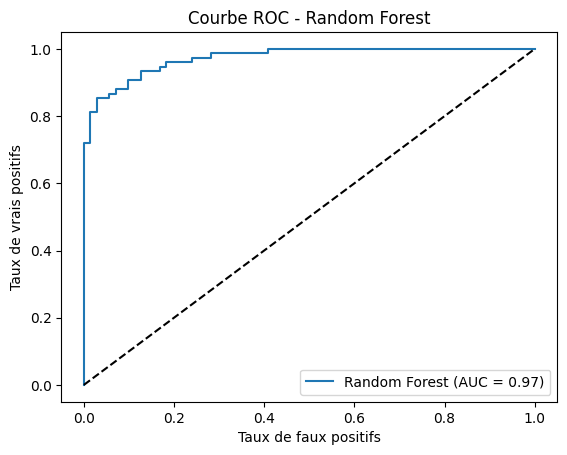

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
plt.plot(fpr, tpr, label="Random Forest (AUC = {:.2f})".format(auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Random Forest")
plt.legend()
plt.show()

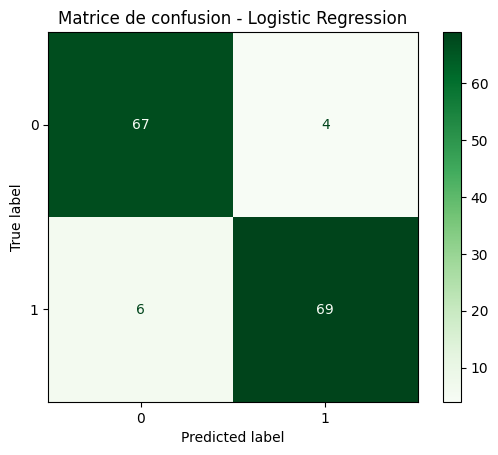

In [17]:
lg = joblib.load("../app/models/lg.pkl")
y_pred_lg = lg.predict(X_test)
y_proba_lg = lg.predict_proba(X_test)[:, 1]
cm_lg = confusion_matrix(y_test, y_pred_lg)
ConfusionMatrixDisplay(cm_lg).plot(cmap="Greens")
plt.title("Matrice de confusion - Logistic Regression")
plt.show()


Rapport de classification : Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        71
           1       0.95      0.92      0.93        75

    accuracy                           0.93       146
   macro avg       0.93      0.93      0.93       146
weighted avg       0.93      0.93      0.93       146



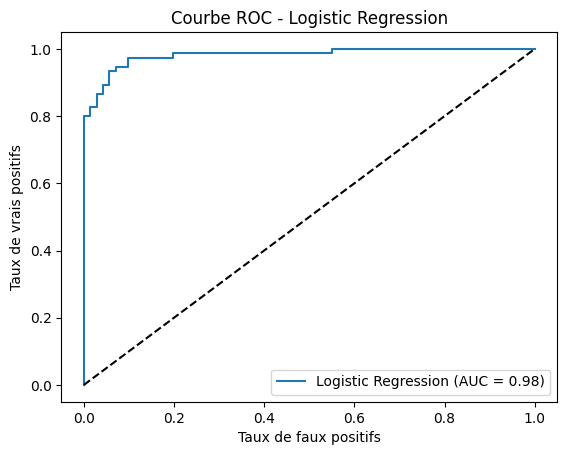

In [18]:
print("Rapport de classification : Logistic Regression")
print(classification_report(y_test, y_pred_lg))
fpr_lg, tpr_lg, _ = roc_curve(y_test, y_proba_lg)
plt.plot(fpr_lg, tpr_lg, label="Logistic Regression (AUC = {:.2f})".format(auc(fpr_lg, tpr_lg)))
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Logistic Regression")
plt.legend()
plt.show()

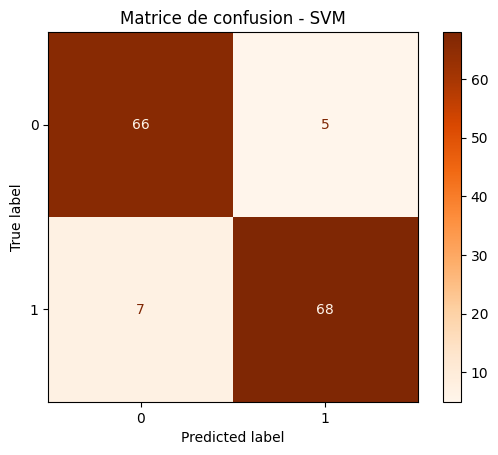

In [19]:
svm = joblib.load("../app/models/svm.pkl")
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm).plot(cmap="Oranges")
plt.title("Matrice de confusion - SVM")
plt.show()


Rapport de classification : SVM
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        71
           1       0.93      0.91      0.92        75

    accuracy                           0.92       146
   macro avg       0.92      0.92      0.92       146
weighted avg       0.92      0.92      0.92       146



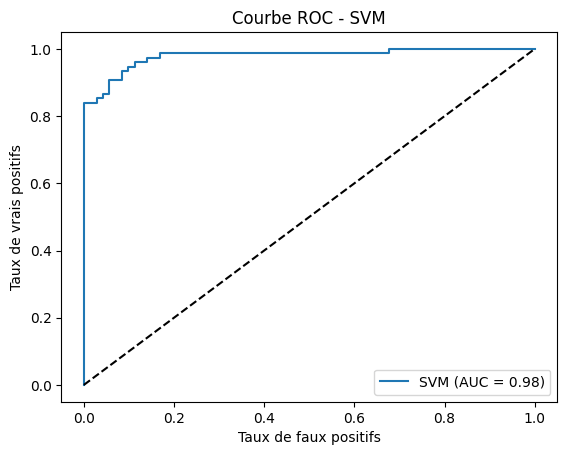

In [20]:
print("Rapport de classification : SVM")
print(classification_report(y_test, y_pred_svm))
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC = {:.2f})".format(auc(fpr_svm, tpr_svm)))
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - SVM")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Matrice de confusion - KNN')

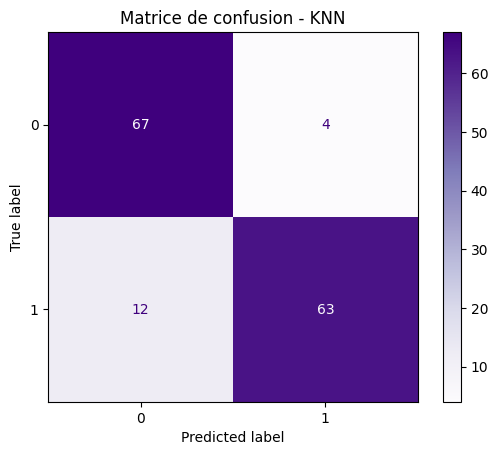

In [21]:
knn = joblib.load("../app/models/knn.pkl")
y_pred_knn = knn.predict(X_test)
# KNN does not have predict_proba if n_neighbors=1, so check first
if hasattr(knn, "predict_proba"):
    y_proba_knn = knn.predict_proba(X_test)[:, 1]
    fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
else:
    y_proba_knn = None
    fpr_knn, tpr_knn = None, None
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot(cmap="Purples")
plt.title("Matrice de confusion - KNN")


Rapport de classification : KNN
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        71
           1       0.94      0.84      0.89        75

    accuracy                           0.89       146
   macro avg       0.89      0.89      0.89       146
weighted avg       0.90      0.89      0.89       146



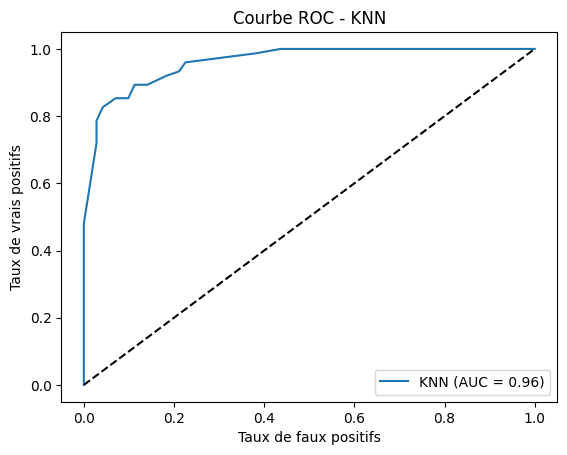

In [22]:
print("Rapport de classification : KNN")
print(classification_report(y_test, y_pred_knn))
if y_proba_knn is not None:
    plt.plot(fpr_knn, tpr_knn, label="KNN (AUC = {:.2f})".format(auc(fpr_knn, tpr_knn)))
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.title("Courbe ROC - KNN")
    plt.legend()
    plt.show()